# Telco Customer Churn Prediction
Machine Learning Classification Project

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# EDA

## Priniting the first 5 rows of data set table

In [6]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## Understanding the size and structure of the dataset.

In [7]:
df.shape

(7043, 21)

## Inspect Dataset Structure

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Target Variable Analysis

This section examines the distribution of the target variable (Churn) to understand how many customers stayed and how many left the telecom service.

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

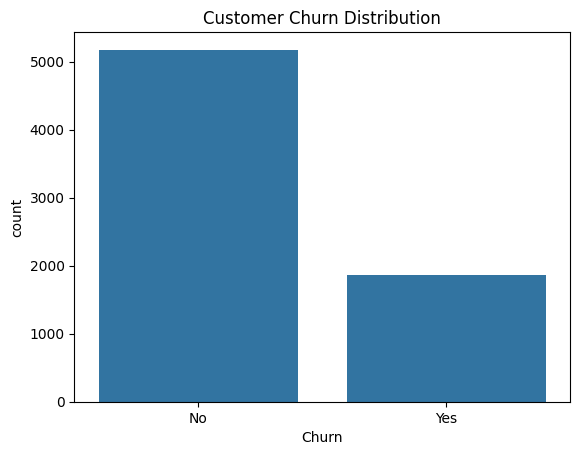

In [10]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Interpretation

The dataset contains 7043 customers. Out of these, 5174 customers (approximately 73.5%) did not churn, while 1869 customers (approximately 26.5%) discontinued the service.

This indicates a moderate class imbalance where the majority class is non-churn customers. Such imbalance can influence model training because machine learning algorithms may become biased toward the majority class. Therefore, evaluation metrics such as precision, recall, and F1-score will be important when assessing model performance.

The dataset is not perfectly balanced,
Accuracy alone may not be reliable,
Recall and F1-score will play a pivotal role in this system,
Stratified train-test splitting will be necessary.

# Feature Type Identification

In [11]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Features:")
print(categorical_columns)

print("\nNumerical Features:")
print(numerical_columns)

Categorical Features:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


### summary 
The dataset contains a larger number of categorical variables compared to numerical variables. This means categorical encoding will be an important preprocessing step before training machine learning models.

# Numerical Feature Distribution

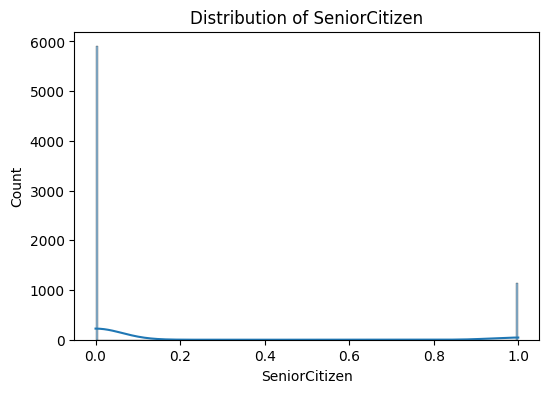

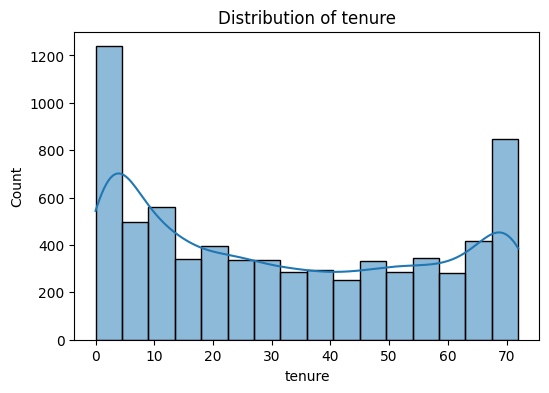

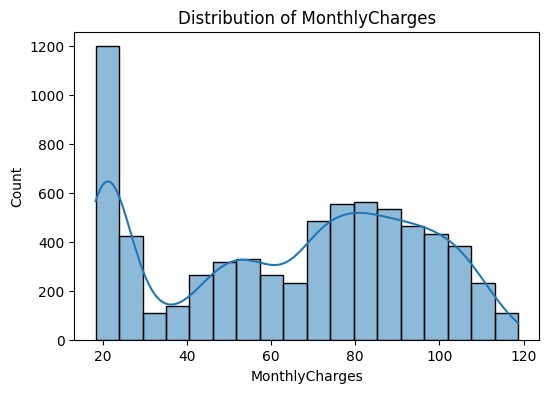

In [12]:
numerical_columns = ['SeniorCitizen','tenure','MonthlyCharges']

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

**Summary:**
 Most customers are not senior citizens, indicating that the telecom service is mainly used by younger customers.

 The presence of many customers with low tenure suggests that newer customers form a large portion of the dataset, which may influence churn behavior.

 Monthly charges vary widely across customers, indicating different service pricing levels that may impact customer retention.

# Contract Type vs Customer Churn
This section examines whether the type of customer contract influences the likelihood of churn.

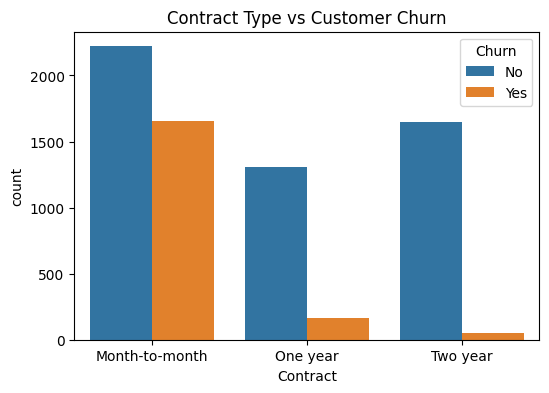

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Customer Churn")
plt.show()

Customers with month-to-month contracts appear to have a higher churn rate compared to customers with longer-term contracts such as one-year or two-year plans.

# Internet Service vs Customer Churn
This section examines whether the type of internet service subscribed to by customers influences their likelihood of churn.

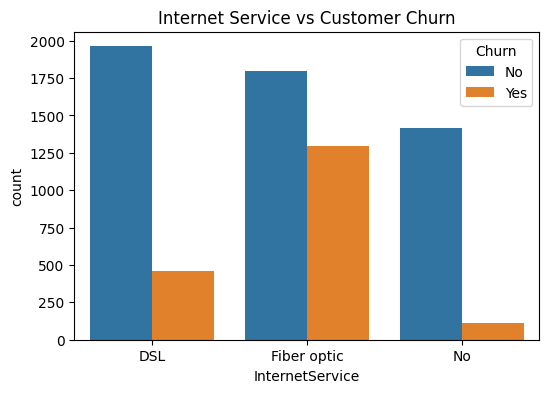

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Customer Churn")
plt.show()

Customers using fiber optic internet service show a significantly higher churn rate compared to customers using DSL or those without internet service. This suggests that customers with fiber optic service may be less satisfied or more likely to switch providers.

# Payment Method vs Customer Churn
This section analyzes whether the payment method used by customers affects their likelihood of churn.

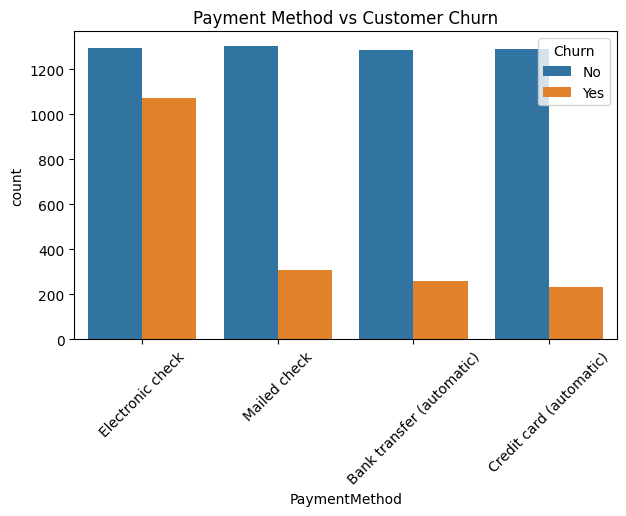

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Customer Churn")
plt.xticks(rotation=45)
plt.show()

Customers using electronic check as their payment method show the highest churn rate compared to other payment methods. Customers using automatic payment methods such as bank transfer or credit card appear to have lower churn rates.

# Tech Support vs Customer Churn
This section investigates whether access to technical support services affects the likelihood of customer churn.

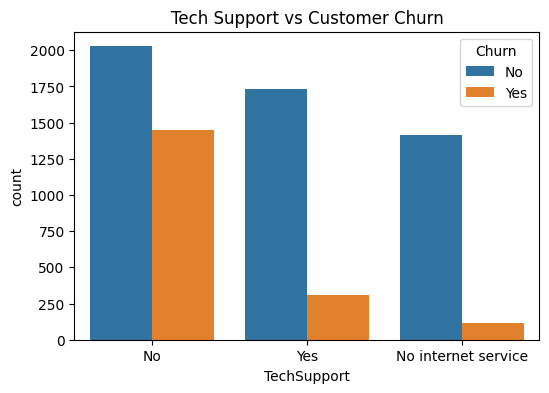

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Customer Churn")
plt.show()

Customers without technical support show a significantly higher churn rate compared to those who have access to tech support services. Customers with technical support appear more likely to remain with the telecom provider.


Lack of technical support appears to be strongly associated with higher churn rates. This suggests that providing reliable customer support services may play a key role in improving customer retention.

# Tenure vs Customer Churn
This section explores how the length of time a customer has stayed with the company influences the likelihood of churn.

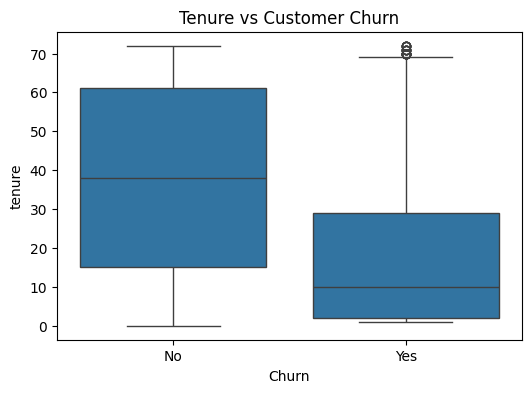

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Customer Churn")
plt.show()

### Summary
Customers who churn generally have much lower tenure compared to customers who stay with the company. This indicates that newer customers are more likely to leave, suggesting that tenure is a strong predictor of customer churn.

# Correlation Analysis

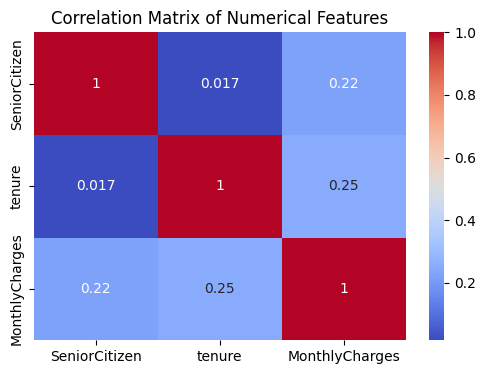

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['SeniorCitizen','tenure','MonthlyCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Summary
The correlation analysis indicates weak relationships among the numerical variables in the dataset. This suggests that multicollinearity is not a significant concern, which is beneficial for building stable and reliable machine learning models.

# Data Preprocessing 
*Removing Irrelevant Features*

This step removes columns that do not contribute to predicting churn and may negatively affect model performance.

In [19]:
df = df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Fixing Data Type Issues


*This step converts columns that are incorrectly stored as text into numerical values so they can be used by machine learning algorithms.*

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


One feature (TotalCharges) was incorrectly stored as a text variable and was converted to a numerical format to allow proper analysis and model training.

# Handling Missing Values



In [22]:
df[df['TotalCharges'].isnull()].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [23]:
df = df.dropna()

# Encoding Categorical Variables


This is used to converts categorical variables into numerical format so that machine learning algorithms can process them.

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [25]:
df_encoded.shape

(7032, 31)

### Summary
Categorical variables were converted into numerical format using one-hot encoding to allow machine learning algorithms to process the data. This transformation expands categorical features into multiple binary variables while preserving their informational content.

# In the report speak about how one hot encoding would be better than dummies, ALSO use standard scaler and make sure all values are numbers. 

# here insert SMOTE

# Splitting Features and Target Variable


This step separates the dataset into input features (X) and the target variable (y) used for predicting customer churn.

In [26]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [27]:
X.shape

(7032, 30)

In [28]:
y.shape

(7032,)

### Summary
The dataset was successfully divided into input features (X) and the target variable (y). Each customer record now has a corresponding churn label that will be used to train the machine learning models.

## Train-Test Split

This step divides the dataset into training data for building the model and testing data for evaluating its performance.

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Summary
The dataset was split into training and testing sets using an 80/20 ratio to allow the model to learn patterns from the training data while evaluating its predictive performance on unseen test data.

# Feature Scaling

This step standardizes numerical features so that all variables contribute equally to machine learning model training.



In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled.shape
X_test_scaled.shape

(1407, 30)

In [33]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5625, 30)
(1407, 30)


### Summary
After scaling and splitting the dataset, 5625 samples were used for training and 1407 samples for testing, with a total of 30 predictive features. The increased feature count resulted from one-hot encoding of categorical variables.

## Baseline Model Development


This section trains machine learning models using default parameters to establish baseline performance before applying optimization techniques.

## Logistic Regression 

Logistic Regression is used as a baseline classifier to evaluate how well churn can be predicted using a simple linear model.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)

accuracy_log

0.7874911158493249

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[915 118]
 [181 193]]
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# optimise them, hyerparameter optimisation ye, so bsaically u wanna iterate thru numbers for hyperparaeters as so to tune them properly. but u can only do this if u have done smote or adasyn

# once uve done that, u will do cross validation 


# SHAP, feature improtance analysis

# also, take a picture of the results uve got now, and reason in the report why u need to make these changes. 

### Summary
The Logistic Regression model achieved an accuracy of approximately 79%. However, the model performs significantly better at predicting non-churn customers compared to churn customers. The recall for churn is relatively low (52%), indicating that the model fails to identify a substantial number of customers who are likely to leave. This highlights the need for further model improvement to enhance churn detection performance.

## MODEL OPTIMIZATION


### Applying Smote on trained data 
SMOTE is applied to balance the training data by generating synthetic samples for the minority class (churn).

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [37]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Churn_Yes
False    4130
True     1495
Name: count, dtype: int64
Churn_Yes
True     4130
False    4130
Name: count, dtype: int64


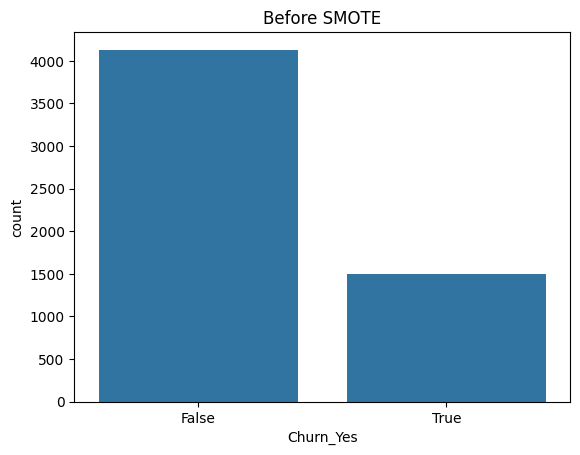

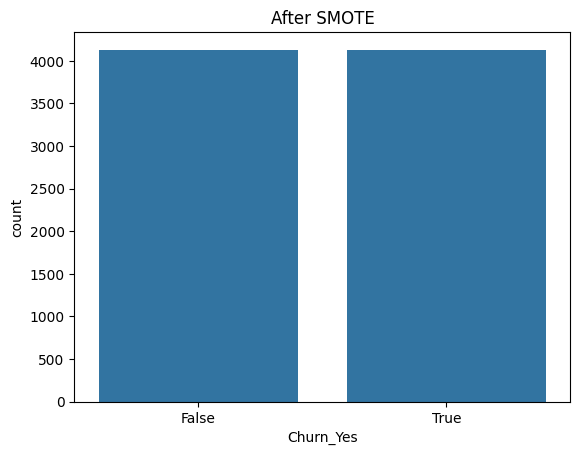

In [38]:
import seaborn as sns

# Before
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

# After
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")
plt.show()

### Conclusion and Important Insight
The visualization clearly shows that the dataset was initially imbalanced, with significantly more non-churn customers than churn customers. After applying SMOTE, the classes became balanced, ensuring that the model can learn equally from both classes and improving its ability to detect churn.

## Scaling After SMOTE
Feature scaling is applied after SMOTE to standardize the newly generated training data before model training.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression After SMOTE
This model will be trained on the balanced dataset after applying SMOTE to evaluate the improvement in churn prediction performance.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
log_model_smote = LogisticRegression()
log_model_smote.fit(X_train_smote_scaled, y_train_smote)

# Predict
y_pred_log_smote = log_model_smote.predict(X_test_scaled)

# Accuracy
accuracy_log_smote = accuracy_score(y_test, y_pred_log_smote)
print("Accuracy:", accuracy_log_smote)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_smote))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_log_smote))

Accuracy: 0.7704335465529495
Confusion Matrix:
 [[847 186]
 [137 237]]
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.82      0.84      1033
        True       0.56      0.63      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



### Summary
After applying SMOTE, the model showed improved performance in detecting churn customers, as evidenced by the increase in recall from 52% to 63%. Although overall accuracy slightly decreased, the model became more effective in identifying customers at risk of leaving. This demonstrates the importance of handling class imbalance in classification problems.

In [41]:
log_model_smote.fit(X_train_smote_scaled, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Summary
The Logistic Regression model was initialized with default hyperparameters, which serve as a baseline before applying hyperparameter optimization techniques.

## Logistic Regression Hyperparameter Optimization
Hyperparameter optimizations will be used to find the best parameter settings that improve the model’s performance.

# First i implement Grid First Search

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

# Initialize model
log = LogisticRegression(max_iter=1000)

# Grid search
grid_log = GridSearchCV(log, param_grid, cv=5)

# Train on SMOTE data
grid_log.fit(X_train_smote_scaled, y_train_smote)

# Best model
best_log = grid_log.best_estimator_

In [43]:
print("Best Parameters:", grid_log.best_params_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}


In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_best = best_log.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))

Accuracy: 0.7725657427149965
Confusion Matrix:
 [[851 182]
 [138 236]]
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.82      0.84      1033
        True       0.56      0.63      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407



### Logistic Regression Performance Comparison

| Metric                | Before SMOTE | After SMOTE | After Optimization |
|---------------------|-------------|------------|-------------------|
| Accuracy            | 0.79        | 0.77       | 0.77              |
| Precision (Churn)   | 0.62        | 0.56       | 0.56              |
| Recall (Churn)      | 0.52 ❌     | 0.63 ✅    | 0.63 ✅           |
| F1-score (Churn)    | 0.56        | 0.59       | 0.60              |
| True Positives      | 193         | 237        | 236               |
| False Negatives     | 181         | 137        | 138               |

Accuracy dropped a bit because after SMOTE, the model stopped favouring the more common class so much and started making more balanced predictions. But recall and F1-score improved since it now does a better job catching churn customers that were previously being missed.


## Randomized Search (Logistic Regression)
RandomizedSearchCV is used to test random combinations of hyperparameters to efficiently find a good model configuration

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter distributions
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

# Initialize model
log = LogisticRegression(max_iter=1000)

# Random search
random_log = RandomizedSearchCV(log, param_dist, n_iter=6, cv=5, random_state=42)

# Train
random_log.fit(X_train_smote_scaled, y_train_smote)

# Best model
best_random_log = random_log.best_estimator_

In [46]:
print("Best Parameters (Random Search):", random_log.best_params_)

Best Parameters (Random Search): {'solver': 'liblinear', 'C': 10}


In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_random = best_random_log.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_random))
print(confusion_matrix(y_test, y_pred_random))
print(classification_report(y_test, y_pred_random))

Accuracy: 0.7725657427149965
[[851 182]
 [138 236]]
              precision    recall  f1-score   support

       False       0.86      0.82      0.84      1033
        True       0.56      0.63      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407



### Comparison of GridSearch and RandomizedSearch

| Method             | Accuracy | Recall (Churn) | F1-score |
|------------------|---------|----------------|----------|
| GridSearchCV      | 0.77    | 0.63           | 0.60     |
| RandomizedSearch  | 0.77    | 0.63           | 0.60     |

Both GridSearchCV and RandomizedSearchCV produced identical results, indicating that RandomizedSearch was sufficient to identify optimal hyperparameters for this model.
This result kind of shows that for relatively simple models and small search spaces, RandomizedSearch can achieve comparable performance to GridSearch with reduced computational cost.

## KNN (Baseline Model)
KNN classifies customers based on the majority class of their nearest neighbors in the dataset.

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_smote_scaled, y_train_smote)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.7171286425017769
Confusion Matrix:
 [[770 263]
 [135 239]]
Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.75      0.79      1033
        True       0.48      0.64      0.55       374

    accuracy                           0.72      1407
   macro avg       0.66      0.69      0.67      1407
weighted avg       0.75      0.72      0.73      1407



### Summary
The baseline KNN model was trained on the SMOTE-balanced dataset to establish a performance benchmark before optimization.

## KNN Hyperparameter Optimization
Hyperparameter tuning is applied to KNN to determine the optimal number of neighbors and distance  metric for improved prediction.

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_nei
    ors': [3,5,7,9],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid_knn.fit(X_train_smote_scaled, y_train_smote)

best_knn = grid_knn.best_estimator_

SyntaxError: unterminated string literal (detected at line 4) (1381745778.py, line 4)

In [ ]:
print("Best Parameters:", grid_knn.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}


In [ ]:
y_pred_knn_opt = best_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn_opt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_opt))
print("Classification Report:\n", classification_report(y_test, y_pred_knn_opt))

Accuracy: 0.720682302771855
Confusion Matrix:
 [[753 280]
 [113 261]]
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.73      0.79      1033
        True       0.48      0.70      0.57       374

    accuracy                           0.72      1407
   macro avg       0.68      0.71      0.68      1407
weighted avg       0.77      0.72      0.73      1407



### KNN Performance Comparison

| Metric                | Baseline KNN | Optimized KNN |
|---------------------|-------------|--------------|
| Accuracy            | 0.72        | 0.72         |
| Recall (Churn)      | 0.64        | 0.70       |
| F1-score (Churn)    | 0.55        | 0.57         |
| True Positives      | 239         | 261          |
| False Negatives     | 135         | 113          |

### Summary
Hyperparameter optimization significantly improved the KNN model, particularly in detecting churn customers, as recall increased from 64% to 70%. The use of Manhattan distance and an optimal number of neighbors enhanced the model’s ability to capture patterns in the data, making it more effective than the baseline model.

## 
The model tested different neighbor sizes and distance metrics, and found that using 7 neighbors with Manhattan distance gave the best performance, improving churn detection by better capturing relationships in the data.

## SVM (Baseline Model)
Support Vector Machine (SVM) classifies data by finding the optimal boundary that best separates different classes.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_model = SVC()

svm_model.fit(X_train_smote_scaled, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.7782515991471215
Confusion Matrix:
 [[847 186]
 [126 248]]
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.82      0.84      1033
        True       0.57      0.66      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



### Summary
The baseline SVM model was trained on the SMOTE-balanced dataset to establish its initial performance before optimization.

## SVM optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(), param_grid, cv=5)

grid_svm.fit(X_train_smote_scaled, y_train_smote)

best_svm = grid_svm.best_estimator_

In [ ]:
print("Best Parameters:", grid_svm.best_params_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}


In [ ]:
y_pred_svm_opt = best_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm_opt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_opt))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_opt))

Accuracy: 0.7569296375266524
Confusion Matrix:
 [[835 198]
 [144 230]]
Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.81      0.83      1033
        True       0.54      0.61      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407



### Summary
Hyperparameter optimization improved the SVM model by selecting the best regularization strength and kernel type, allowing it to better separate churn and non-churn customers.

### SVM Performance Comparison

| Metric                | Baseline SVM | Optimized SVM |
|---------------------|-------------|--------------|
| Accuracy            | 0.78        | 0.76         |
| Precision (Churn)   | 0.57        | 0.54         |
| Recall (Churn)      | 0.66        | 0.61         |
| F1-score (Churn)    | 0.61        | 0.57         |
| True Positives      | 248         | 230          |
| False Negatives     | 126         | 144          |

The optimized SVM model showed a slight decrease in performance compared to the baseline, indicating that the chosen hyperparameters did not improve the model for this dataset.

The SVM model achieved strong baseline performance; however, hyperparameter optimization led to a slight decrease in accuracy and recall. This indicates that the default model parameters were already well-suited for the dataset, and further tuning introduced unnecessary complexity, reducing generalization performance.

## Naive Bayes (Baseline Model )
Naive Bayes is a probabilistic classifier that predicts churn based on the likelihood of features assuming independence.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_model = GaussianNB()

nb_model.fit(X_train_smote_scaled, y_train_smote)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.6240227434257285
Confusion Matrix:
 [[540 493]
 [ 36 338]]
Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.52      0.67      1033
        True       0.41      0.90      0.56       374

    accuracy                           0.62      1407
   macro avg       0.67      0.71      0.62      1407
weighted avg       0.80      0.62      0.64      1407



### Summary
The baseline Naive Bayes model was applied to the SMOTE-balanced dataset to evaluate its initial probabilistic classification performance.

# Optimization of Naivebayes

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

grid_nb = GridSearchCV(GaussianNB(), param_grid, cv=5)

grid_nb.fit(X_train_smote_scaled, y_train_smote)

best_nb = grid_nb.best_estimator_

In [ ]:
print("Best Parameters:", grid_nb.best_params_)

Best Parameters: {'var_smoothing': 1e-09}


In [ ]:
y_pred_nb_opt = best_nb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nb_opt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_opt))
print("Classification Report:\n", classification_report(y_test, y_pred_nb_opt))

Accuracy: 0.6240227434257285
Confusion Matrix:
 [[540 493]
 [ 36 338]]
Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.52      0.67      1033
        True       0.41      0.90      0.56       374

    accuracy                           0.62      1407
   macro avg       0.67      0.71      0.62      1407
weighted avg       0.80      0.62      0.64      1407



### Summary
Hyperparameter tuning adjusted the smoothing parameter in Naive Bayes, allowing the model to better handle feature distributions and improve prediction stability.

### Naive Bayes Performance Comparison

| Metric                | Baseline NB | Optimized NB |
|---------------------|------------|-------------|
| Accuracy            | 0.62       | 0.62        |
| Precision (Churn)   | 0.41       | 0.41        |
| Recall (Churn)      | 0.90       | 0.90        |
| F1-score (Churn)    | 0.56       | 0.56        |
| True Positives      | 338        | 338         |
| False Negatives     | 36         | 36          |

Naive Bayes achieved very high recall but low precision, indicating that while it effectively detects churn customers, it produces many false positives due to its strong independence assumption.

# KNN CROSS VALIDATION
Cross-validation is applied to evaluate the stability and generalization performance of the optimized KNN model across multiple folds.

In [ ]:
from sklearn.model_selection import cross_val_score

knn_scores = cross_val_score(
    best_knn,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("KNN Fold Scores:", knn_scores)
print("KNN Mean Accuracy:", knn_scores.mean())

from sklearn.model_selection import cross_val_score

knn_recall_scores = cross_val_score(
    best_knn,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='recall'
)

print("KNN Recall Fold Scores:", knn_recall_scores)
print("KNN Mean Recall:", knn_recall_scores.mean())

knn_f1_scores = cross_val_score(
    best_knn,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("KNN F1 Fold Scores:", knn_f1_scores)
print("KNN Mean F1:", knn_f1_scores.mean())

KNN Fold Scores: [0.75363196 0.76997579 0.82384988 0.84322034 0.84382567]
KNN Mean Accuracy: 0.8069007263922519
KNN Recall Fold Scores: [0.7409201  0.78087167 0.94067797 0.94188862 0.92857143]
KNN Mean Recall: 0.8665859564164649
KNN F1 Fold Scores: [0.75045984 0.77245509 0.84227642 0.85730028 0.85602679]
KNN Mean F1: 0.8157036828739125


# Cross Validation (Logestic Regression)
Cross-validation is applied to evaluate the consistency of the optimized Logistic Regression model across multiple folds.

In [ ]:
log_scores = cross_val_score(
    best_log,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("Logistic Fold Scores:", log_scores)
print("Logistic Mean Accuracy:", log_scores.mean())

log_recall_scores = cross_val_score(
    best_log,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='recall'
)

print("Logistic Recall Fold Scores:", log_recall_scores)
print("Logistic Mean Recall:", log_recall_scores.mean())

log_f1_scores = cross_val_score(
    best_log,
    X_train_smote_scaled,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("Logistic F1 Fold Scores:", log_f1_scores)
print("Logistic Mean F1:", log_f1_scores.mean())

Logistic Fold Scores: [0.71246973 0.75423729 0.86864407 0.88377724 0.88922518]
Logistic Mean Accuracy: 0.8216707021791768
Logistic Recall Fold Scores: [0.53389831 0.65254237 0.94430993 0.94430993 0.94188862]
Logistic Mean Recall: 0.8033898305084746
Logistic F1 Fold Scores: [0.64996315 0.72641509 0.87788407 0.89041096 0.89476711]
Logistic Mean F1: 0.8078880778151017


### Cross-Validation Performance Comparison

| Model                | Mean CV Accuracy | Lowest Fold | Highest Fold | Stability |
|---------------------|-----------------|------------|-------------|----------|
| KNN                 | 0.807           | 0.754      | 0.844       | Good |
| Logistic Regression | 0.822           | 0.712      | 0.889       | Moderate |

Cross-validation revealed a clear trade-off between overall generalization and churn detection performance. Logistic Regression achieved the highest mean accuracy (0.822), indicating stronger overall predictive robustness, while KNN produced higher mean recall (0.867) and F1-score (0.816), demonstrating superior performance in identifying churn customers and balancing classification performance. These findings reinforce KNN as the preferred model for churn prediction, despite Logistic Regression showing slightly stronger generalization.

### Cross-Validation Performance Comparison

| Model | Mean CV Accuracy | Mean Recall | Mean F1 | Stability | Interpretation |
|------|------------------|------------|---------|----------|----------------|
| KNN | 0.807 | 0.867 | 0.816 | Good | Best for churn detection ✅ |
| Logistic Regression | 0.822 | 0.803 | 0.808 | Moderate | Best generalization |

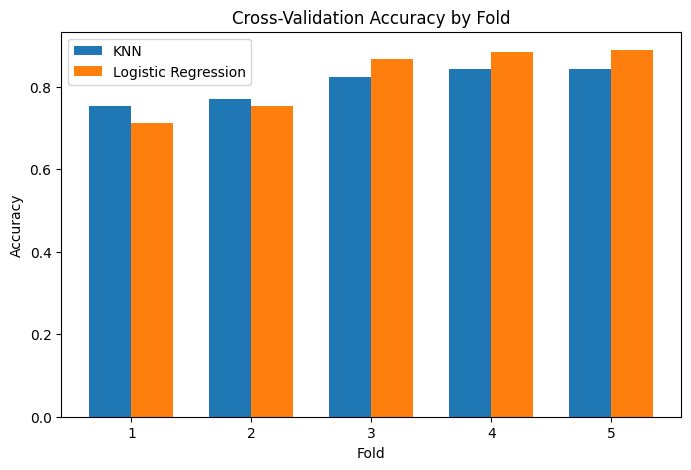

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fold scores
knn_scores = [0.7536, 0.7700, 0.8238, 0.8432, 0.8438]
log_scores = [0.7125, 0.7542, 0.8686, 0.8838, 0.8892]

folds = np.arange(1,6)

width = 0.35

plt.figure(figsize=(8,5))
plt.bar(folds - width/2, knn_scores, width, label='KNN')
plt.bar(folds + width/2, log_scores, width, label='Logistic Regression')

plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy by Fold')
plt.legend()

plt.show()

The cross-validation accuracy graph shows Logistic Regression achieved slightly higher overall generalization performance, while KNN maintained competitive and consistent accuracy across folds.

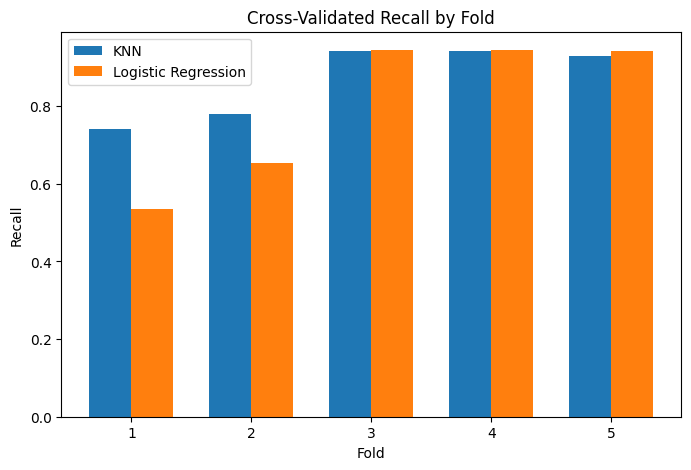

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recall scores from your output
knn_recall = [0.7409, 0.7809, 0.9407, 0.9419, 0.9286]
log_recall = [0.5339, 0.6525, 0.9443, 0.9443, 0.9419]

folds = np.arange(1,6)

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(folds - width/2, knn_recall, width, label='KNN')
plt.bar(folds + width/2, log_recall, width, label='Logistic Regression')

plt.xlabel('Fold')
plt.ylabel('Recall')
plt.title('Cross-Validated Recall by Fold')
plt.xticks(folds)
plt.legend()

plt.show()

The cross-validation recall graph shows KNN achieved stronger and more balanced churn detection performance across folds, despite Logistic Regression improving in later folds.

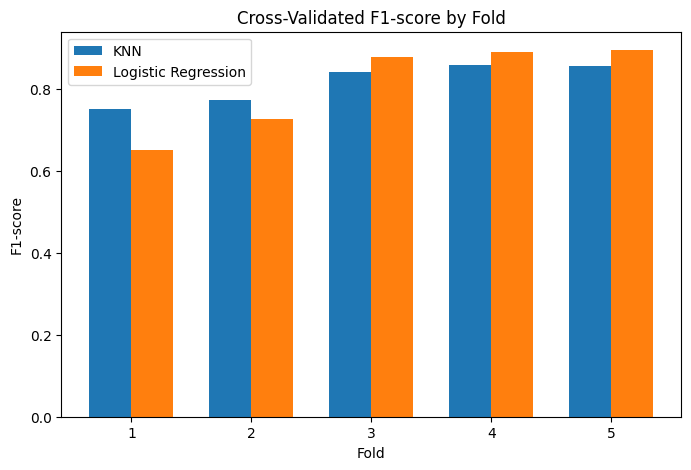

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# F1 scores from your results
knn_f1 = [0.7505, 0.7725, 0.8423, 0.8573, 0.8560]
log_f1 = [0.6500, 0.7264, 0.8779, 0.8904, 0.8948]

folds = np.arange(1,6)

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(folds - width/2, knn_f1, width, label='KNN')
plt.bar(folds + width/2, log_f1, width, label='Logistic Regression')

plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.title('Cross-Validated F1-score by Fold')
plt.xticks(folds)
plt.legend()

plt.show()

The cross-validation F1-score graph shows KNN achieved slightly better overall balance between precision and recall, while Logistic Regression performed strongly in later folds.

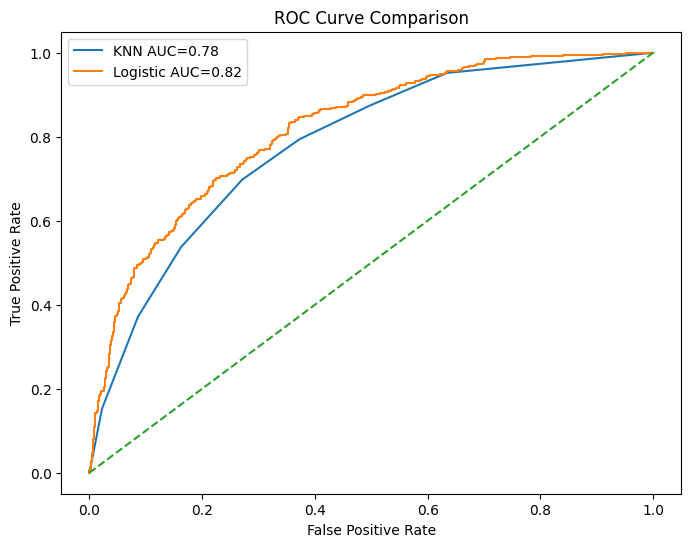

KNN AUC: 0.781923787732113
Logistic AUC: 0.8186606685268493


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:,1]
y_prob_log = best_log.predict_proba(X_test_scaled)[:,1]

# KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Logistic ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN AUC={auc_knn:.2f}')
plt.plot(fpr_log, tpr_log, label=f'Logistic AUC={auc_log:.2f}')

plt.plot([0,1],[0,1],'--')  # random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

print("KNN AUC:", auc_knn)
print("Logistic AUC:", auc_log)

###  ROC curve comparison of KNN and Logistic Regression showing model discrimination performance across thresholds.

# LIME 
LIME is used to explain individual predictions from the selected KNN model by identifying the features influencing churn classification.

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_smote_scaled,
    feature_names=X.columns,
    class_names=['No Churn','Churn'],
    discretize_continuous=True
)

In [ ]:
exp = explainer.explain_instance(
    X_test_scaled[0],         # first test customer
    best_knn.predict_proba
)
print(exp.as_list())

[('tenure > 0.88', -0.10854094732650647), ('Contract_Two year > -0.47', -0.10648968053195244), ('SeniorCitizen > -0.39', -0.09915370979307224), ('PaymentMethod_Electronic check <= -0.96', -0.09392299796706789), ('MultipleLines_No phone service <= -0.35', -0.06715089405405596), ('StreamingMovies_Yes <= -0.92', -0.06411608586250872), ('InternetService_Fiber optic <= -1.08', -0.0614849140873413), ('PaymentMethod_Mailed check <= -0.56', -0.061236274904847406), ('-0.96 < MultipleLines_Yes <= 1.04', 0.060161696865351603), ('PaymentMethod_Credit card (automatic) <= -0.53', -0.05383502418902375)]


LIME analysis indicated that longer tenure and two-year contracts reduced churn risk, while having multiple lines contributed positively to churn prediction.

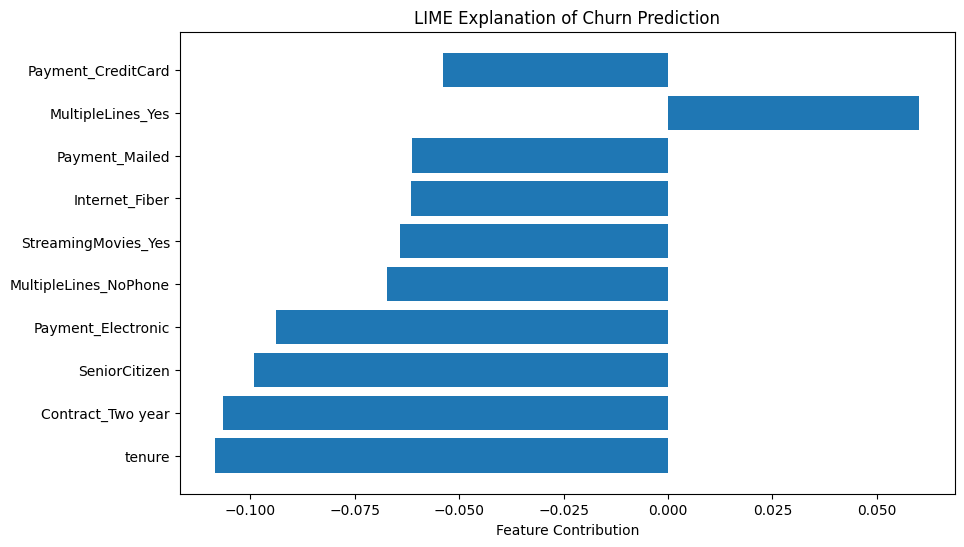

In [ ]:
import matplotlib.pyplot as plt

features = [
'tenure',
'Contract_Two year',
'SeniorCitizen',
'Payment_Electronic',
'MultipleLines_NoPhone',
'StreamingMovies_Yes',
'Internet_Fiber',
'Payment_Mailed',
'MultipleLines_Yes',
'Payment_CreditCard'
]

weights = [
-0.1085,
-0.1065,
-0.0992,
-0.0939,
-0.0672,
-0.0641,
-0.0615,
-0.0612,
0.0602,
-0.0538
]

plt.figure(figsize=(10,6))

plt.barh(features, weights)

plt.xlabel('Feature Contribution')
plt.title('LIME Explanation of Churn Prediction')

plt.show()

#### An important insight from LIME is that the model’s explanations align with expected churn behaviour, supporting the credibility and interpretability of the prediction.

# Correlation Matrix
A correlation matrix shows the strength and direction of relationships between variables, helping identify patterns, dependencies, and potential multicollinearity in the dataset.

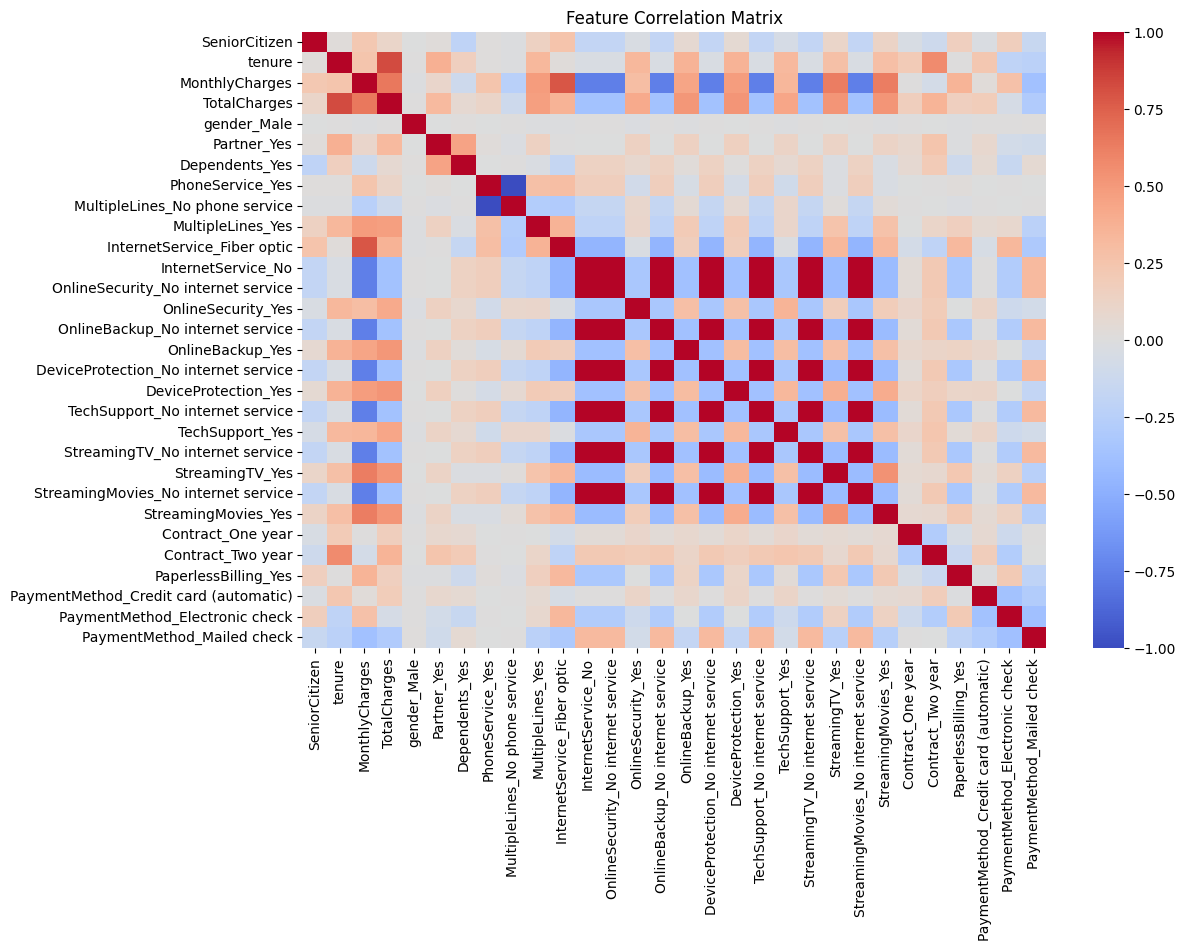

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')

plt.show()

 The correlation matrix indicated some localized redundancy, particularly between tenure and TotalCharges, as well as among service-related features. However, no widespread severe multicollinearity was observed, suggesting the feature set remained suitable for modeling.An important insight was that correlation analysis supported findings from LIME, reinforcing the relevance of tenure-related factors in churn prediction.

# Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['tenure', 'InternetService_Fiber optic',
       'OnlineSecurity_No internet service',
       'OnlineBackup_No internet service',
       'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'StreamingTV_No internet service',
       'StreamingMovies_No internet service', 'Contract_Two year',
       'PaymentMethod_Electronic check'],
      dtype='object')


In [ ]:
import pandas as pd

scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

scores = scores.sort_values(
    by='Score',
    ascending=False
)

print(scores.head(10))

                                 Feature        Score
1                                 tenure  1007.509431
10           InternetService_Fiber optic   733.951530
25                     Contract_Two year   703.210304
28        PaymentMethod_Electronic check   702.709162
11                    InternetService_No   383.981781
12    OnlineSecurity_No internet service   383.981781
16  DeviceProtection_No internet service   383.981781
18       TechSupport_No internet service   383.981781
22   StreamingMovies_No internet service   383.981781
20       StreamingTV_No internet service   383.981781


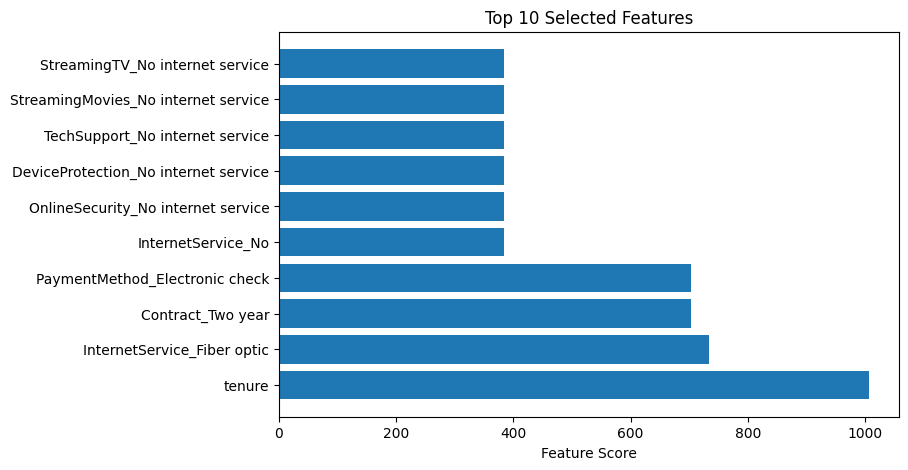

In [ ]:
top10 = scores.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Score']
)

plt.title('Top 10 Selected Features')
plt.xlabel('Feature Score')

plt.show()

Feature selection identified tenure as the strongest predictor, followed by contract type, payment method and internet service-related variables. Importantly, these findings aligned with both correlation analysis and LIME explanations, reinforcing the relevance of these predictors in churn classification.

## Cross-validation confirmed model stability, ROC demonstrated strong class separation, correlation analysis showed acceptable feature relationships, and LIME provided interpretable insights into individual predictions.

## XGBoost is a gradient boosting algorithm that builds decision trees sequentially to minimize errors and improve predictive performance.

## Three iterations will be made and the parametrs will be adjusted to determine the best parameters that produces the most efficient output

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_1 = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200]
}

grid_xgb_1 = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid_1,
    cv=5,
    scoring='f1'
)

grid_xgb_1.fit(X_train_smote_scaled, y_train_smote)

print("Iteration 1 Best:", grid_xgb_1.best_params_)

Iteration 1 Best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [54]:
best_xgb_1 = grid_xgb_1.best_estimator_

y_pred_xgb_1 = best_xgb_1.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_1))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_1))

Accuracy: 0.7640369580668088
Confusion Matrix:
 [[828 205]
 [127 247]]
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.80      0.83      1033
        True       0.55      0.66      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407



In [55]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_2 = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200]
}

grid_xgb_2 = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=2.7  # important addition
    ),
    param_grid_2,
    cv=5,
    scoring='f1'
)

grid_xgb_2.fit(X_train_smote_scaled, y_train_smote)

print("Iteration 2 Best:", grid_xgb_2.best_params_)

Iteration 2 Best: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [56]:
best_xgb_2 = grid_xgb_2.best_estimator_

y_pred_xgb_2 = best_xgb_2.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_2))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_2))

Accuracy: 0.7391613361762616
Confusion Matrix:
 [[805 228]
 [139 235]]
Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.78      0.81      1033
        True       0.51      0.63      0.56       374

    accuracy                           0.74      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.74      0.75      1407



In [57]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_3 = {
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'n_estimators': [200, 300]
}

grid_xgb_3 = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid_3,
    cv=5,
    scoring='f1'
)

grid_xgb_3.fit(X_train_smote_scaled, y_train_smote)

print("Iteration 3 Best:", grid_xgb_3.best_params_)

Iteration 3 Best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


In [59]:
best_xgb_3 = grid_xgb_3.best_estimator_

y_pred_xgb_3 = best_xgb_3.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_3))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_3))

Accuracy: 0.759772565742715
Confusion Matrix:
 [[834 199]
 [139 235]]
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.81      0.83      1033
        True       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407



| Model                  | Accuracy | Precision (0) | Precision (1) | Recall (0) | Recall (1) | F1-score (0) | F1-score (1) |
|------------------------|----------|---------------|---------------|------------|------------|--------------|--------------|
| Logistic Regression    | 0.77     | 0.86          | 0.56          | 0.82       | 0.63       | 0.84         | 0.60         |
| KNN                    | 0.72     | 0.87          | 0.48          | 0.73       | 0.70       | 0.79         | 0.57         |
| SVM                    | 0.76     | 0.85          | 0.54          | 0.81       | 0.61       | 0.83         | 0.57         |
| Naive Bayes            | 0.62     | 0.94          | 0.41          | 0.52       | 0.90       | 0.67         | 0.56         |
| XGBoost (Iteration 1)  | 0.76     | 0.87          | 0.55          | 0.80       | 0.66       | 0.83         | 0.60         |
| XGBoost (Iteration 2)  | 0.74     | 0.85          | 0.51          | 0.78       | 0.63       | 0.81         | 0.56         |
| XGBoost (Iteration 3)  | 0.76     | 0.86          | 0.54          | 0.81       | 0.63       | 0.83         | 0.58         |

This table presents the comparative performance of all evaluated models across key classification metrics. The results show that while most models achieved relatively high accuracy, performance on the minority class (churn) remained lower, highlighting the impact of class imbalance. XGBoost Iteration 1 achieved the best recall for churn detection, while Iteration 3 provided the most balanced overall performance. Naive Bayes demonstrated high recall for the minority class but at the expense of overall accuracy,Although Naive Bayes achieved high recall for churn detection, this was accompanied by a substantial increase in false positives, suggesting that the model prioritised minority class prediction at the expense of overall classification reliability.

